# A Hybrid Movie Recommender: Collaborative and Content-Based Filtering

## Overview

This project builds a movie recommender system from first principles and combines two complementary approaches into a single hybrid model. It uses the MovieLens dataset (100,836 ratings from 610 users across 9,724 movies), a standard real-world benchmark for recommendation.

The work is organized around three components:

1. **Collaborative filtering**, which recommends movies based on the rating patterns of similar users and items, implemented from scratch using item-item cosine similarity.
2. **Content-based filtering**, which recommends movies similar in genre to those a user already likes, implemented from scratch from the movie genre metadata.
3. **A hybrid model** that combines the two into a single ranking, with its rating-prediction accuracy validated against held-out data and compared to sensible baselines.

The two methods address different weaknesses. Collaborative filtering captures taste patterns that genre labels miss, but cannot recommend a movie that no one has rated yet. Content-based filtering can recommend any movie with metadata, including new ones, but is limited to surface similarity. Combining them is the standard production approach, and the dataset here supports a genuine join because every rated movie also has genre metadata.

## Outline

**0 - Setup and data loading**

**1 - Exploring the data**

**2 - Collaborative filtering from scratch**
  - 2.1 The user-item matrix
  - 2.2 Item-item similarity
  - 2.3 Predicting ratings

**3 - Content-based filtering from scratch**
  - 3.1 Genre feature vectors
  - 3.2 Content similarity and recommendations

**4 - The hybrid model**

**5 - Validation: prediction accuracy against baselines**

**6 - Reflection**

## 0. Setup and data loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
# Both files ship with the repository, so the notebook runs without network access.
movies = pd.read_csv('movies.csv')      # movieId, title, genres
ratings = pd.read_csv('ratings.csv')    # userId, movieId, rating, timestamp

print(f"Movies: {movies.shape[0]} | Ratings: {ratings.shape[0]}")
print(f"Users: {ratings['userId'].nunique()} | Rated movies: {ratings['movieId'].nunique()}")
print(f"Rating scale: {ratings['rating'].min()} to {ratings['rating'].max()}")
movies.head(3)

Movies: 9742 | Ratings: 100836
Users: 610 | Rated movies: 9724
Rating scale: 0.5 to 5.0


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


---

## Part 1: Exploring the data

Before modeling, a quick look at the rating distribution and the sparsity of the user-item matrix. Sparsity is the defining feature of recommendation problems: most users have rated only a tiny fraction of all movies.

Matrix sparsity: 98.30% of user-movie pairs are unrated


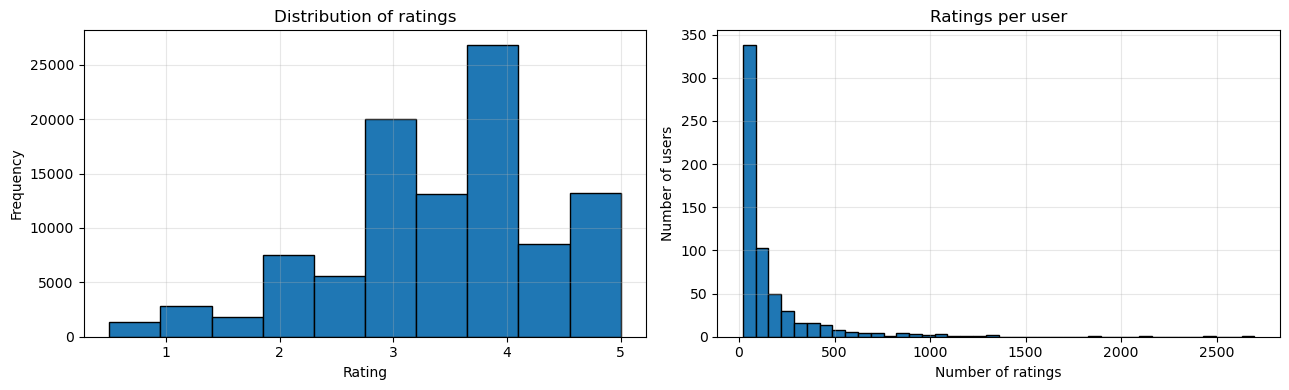

In [3]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
sparsity = 1 - len(ratings) / (n_users * n_movies)
print(f"Matrix sparsity: {100*sparsity:.2f}% of user-movie pairs are unrated")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ratings['rating'].plot(kind='hist', bins=10, ax=axes[0], edgecolor='black')
axes[0].set_title('Distribution of ratings')
axes[0].set_xlabel('Rating')

ratings_per_user = ratings.groupby('userId').size()
axes[1].hist(ratings_per_user, bins=40, edgecolor='black')
axes[1].set_title('Ratings per user')
axes[1].set_xlabel('Number of ratings')
axes[1].set_ylabel('Number of users')
plt.tight_layout()
plt.show()

The matrix is more than 98 percent empty, which is typical and is precisely why recommendation is hard: the model must predict the unrated majority from the rated minority. Most users rate relatively few movies, while a small number are very active.

---

## Part 2: Collaborative Filtering from Scratch

### 2.1 The user-item matrix

Collaborative filtering rests on a simple idea: if two movies are rated similarly by the same users, they are alike, and a user who liked one will probably like the other. This is **item-item collaborative filtering**. The first step is to arrange the ratings into a matrix with users as rows and movies as columns.

In [4]:
# Hold out 20% of ratings for validation later
train_ratings, test_ratings = train_test_split(
    ratings, test_size=0.2, random_state=RANDOM_SEED
)

# Build the user-item matrix from the training ratings only
user_item = train_ratings.pivot_table(index='userId', columns='movieId', values='rating')
print(f"User-item matrix shape: {user_item.shape}  (users x movies)")
print(f"Filled entries: {user_item.notna().sum().sum()} of {user_item.size}")

User-item matrix shape: (610, 8983)  (users x movies)
Filled entries: 80668 of 5479630


### 2.2 Item-item similarity

To measure how similar two movies are, we treat each movie as a vector of the ratings it received across users and compute the **cosine similarity** between those vectors. Cosine similarity measures the angle between two vectors, so it captures whether two movies are rated in the same pattern regardless of overall rating magnitude.

$$\text{sim}(i, j) = \frac{\mathbf{r}_i \cdot \mathbf{r}_j}{\lVert \mathbf{r}_i \rVert \, \lVert \mathbf{r}_j \rVert}$$

We mean-center each user's ratings first so that a user who rates everything highly does not dominate, then fill unrated entries with zero so that only co-rated movies contribute to the similarity.

In [5]:
# Mean-center each user's ratings (subtract that user's average), then fill blanks with 0
user_means = user_item.mean(axis=1)
centered = user_item.sub(user_means, axis=0).fillna(0)

# Movies are columns; we want item-item similarity, so work with the transpose (movies x users)
M = centered.T.values   # shape: (n_movies, n_users)
movie_ids = list(centered.columns)

# Cosine similarity between every pair of movies, computed from scratch
norms = np.linalg.norm(M, axis=1, keepdims=True)
norms[norms == 0] = 1e-9                      # avoid division by zero for unrated movies
M_normalized = M / norms
item_sim = M_normalized @ M_normalized.T      # (n_movies x n_movies) similarity matrix

print(f"Item-item similarity matrix: {item_sim.shape}")
movieid_to_idx = {mid: k for k, mid in enumerate(movie_ids)}

Item-item similarity matrix: (8983, 8983)


### 2.3 Predicting ratings

To predict how a user would rate a target movie, we take the movies that user has already rated, weight each by its similarity to the target movie, and form a similarity-weighted average of those ratings. Adding the prediction back onto the user's mean rating returns it to the original scale.

In [6]:
def predict_cf(user_id, movie_id, k=30):
    """Predict a user's rating for a movie using item-item collaborative filtering.
    Uses the k most similar movies that the user has already rated."""
    if movie_id not in movieid_to_idx or user_id not in user_item.index:
        return user_means.mean()                      # global fallback
    target_idx = movieid_to_idx[movie_id]
    user_ratings = user_item.loc[user_id].dropna()
    if len(user_ratings) == 0:
        return user_means.mean()
    # Similarities between the target movie and the movies the user has rated
    rated_idx = [movieid_to_idx[m] for m in user_ratings.index if m in movieid_to_idx]
    rated_movie_ids = [m for m in user_ratings.index if m in movieid_to_idx]
    sims = item_sim[target_idx, rated_idx]
    # Keep the k most similar
    if len(sims) > k:
        top = np.argsort(sims)[-k:]
        sims = sims[top]
        rated_movie_ids = [rated_movie_ids[t] for t in top]
    centered_ratings = np.array([user_item.loc[user_id, m] - user_means[user_id] for m in rated_movie_ids])
    denom = np.sum(np.abs(sims))
    if denom < 1e-9:
        return user_means[user_id]
    prediction = user_means[user_id] + np.dot(sims, centered_ratings) / denom
    return np.clip(prediction, 0.5, 5.0)

# Quick demonstration
example_user = user_item.index[0]
example_movie = movie_ids[10]
print(f"Predicted rating for user {example_user} on movie {example_movie}: {predict_cf(example_user, example_movie):.2f}")

Predicted rating for user 1 on movie 11: 4.25


---

## Part 3: Content-Based Filtering from Scratch

### 3.1 Genre feature vectors

Content-based filtering ignores other users entirely and instead recommends movies that are intrinsically similar to ones a user likes. Here the content is the genre metadata. Each movie is encoded as a binary vector over the full set of genres, a representation known as multi-hot encoding.

In [7]:
# Build the set of all genres, then a binary genre matrix (movies x genres)
movies_indexed = movies.set_index('movieId')
all_genres = sorted({g for genres in movies['genres'] for g in genres.split('|')})
genre_to_col = {g: c for c, g in enumerate(all_genres)}

genre_matrix = np.zeros((len(movies), len(all_genres)))
movie_row_ids = list(movies['movieId'])
movieid_to_row = {mid: r for r, mid in enumerate(movie_row_ids)}
for r, genres in enumerate(movies['genres']):
    for g in genres.split('|'):
        genre_matrix[r, genre_to_col[g]] = 1

print(f"Genre matrix: {genre_matrix.shape}  (movies x genres)")
print(f"Genres: {all_genres}")

Genre matrix: (9742, 20)  (movies x genres)
Genres: ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


### 3.2 Content similarity and recommendations

Two movies are considered similar in content if their genre vectors point in a similar direction, again measured by cosine similarity. To recommend for a user, we build a profile of the genres they tend to rate highly and score every movie by similarity to that profile.

In [8]:
# Normalize genre vectors for cosine similarity
g_norms = np.linalg.norm(genre_matrix, axis=1, keepdims=True)
g_norms[g_norms == 0] = 1e-9
genre_normalized = genre_matrix / g_norms

def user_genre_profile(user_id):
    """Build a genre preference vector for a user, weighted by how highly they rated each movie."""
    user_ratings = train_ratings[train_ratings['userId'] == user_id]
    profile = np.zeros(len(all_genres))
    for _, row in user_ratings.iterrows():
        if row['movieId'] in movieid_to_row:
            profile += row['rating'] * genre_matrix[movieid_to_row[row['movieId']]]
    norm = np.linalg.norm(profile)
    return profile / norm if norm > 0 else profile

def predict_content(user_id, movie_id):
    """Score a movie for a user by cosine similarity between the user's genre profile and the movie's genres.
    Returns a score on the rating scale."""
    if movie_id not in movieid_to_row:
        return user_means.get(user_id, 3.0)
    profile = user_genre_profile(user_id)
    movie_vec = genre_normalized[movieid_to_row[movie_id]]
    similarity = np.dot(profile, movie_vec)         # in [0, 1]
    # Map similarity to the rating scale, centered on the user's average
    base = user_means[user_id] if user_id in user_means.index else 3.0
    return np.clip(base + (similarity - 0.5) * 2, 0.5, 5.0)

example_user = user_item.index[0]
print(f"Content-based predicted rating for user {example_user} on movie {movie_ids[10]}: "
      f"{predict_content(example_user, movie_ids[10]):.2f}")

Content-based predicted rating for user 1 on movie 11: 4.38


---

## Part 4: The Hybrid Model

The hybrid combines the two predictions with a weighting parameter alpha. When alpha is 1 the model is pure collaborative filtering; when alpha is 0 it is pure content-based. A value in between blends the two, drawing on collaborative taste patterns where they are available and falling back on content similarity otherwise.

$$\hat{r}_{\text{hybrid}} = \alpha \, \hat{r}_{\text{CF}} + (1 - \alpha) \, \hat{r}_{\text{content}}$$

In [9]:
def predict_hybrid(user_id, movie_id, alpha=0.7):
    cf = predict_cf(user_id, movie_id)
    content = predict_content(user_id, movie_id)
    return alpha * cf + (1 - alpha) * content

---

## Part 5: Validation: Prediction Accuracy Against Baselines

A recommender's rating predictions can be evaluated against held-out ratings using root mean squared error (RMSE), the typical error of a predicted rating on the 0.5 to 5.0 scale. We compare four models: two simple baselines, the two individual methods, and the hybrid. A sample of the test set is used to keep the evaluation tractable, since the from-scratch predictors are not optimized for speed.

In [10]:
# Evaluate on a random sample of the held-out test ratings
test_sample = test_ratings.sample(n=2000, random_state=RANDOM_SEED)
global_mean = train_ratings['rating'].mean()

def rmse_of(predict_fn):
    preds, actuals = [], []
    for _, row in test_sample.iterrows():
        preds.append(predict_fn(row['userId'], row['movieId']))
        actuals.append(row['rating'])
    return np.sqrt(mean_squared_error(actuals, preds))

# Baseline 1: always predict the global mean rating
rmse_global = np.sqrt(mean_squared_error(
    test_sample['rating'], [global_mean] * len(test_sample)))
# Baseline 2: predict each user's own mean rating
rmse_user_mean = rmse_of(lambda u, m: user_means[u] if u in user_means.index else global_mean)
# The three real models
rmse_cf = rmse_of(predict_cf)
rmse_content = rmse_of(predict_content)
rmse_hybrid = rmse_of(lambda u, m: predict_hybrid(u, m, alpha=0.7))

print(f"{'Model':<32}{'RMSE':>8}")
print('-' * 40)
print(f"{'Global mean (baseline)':<32}{rmse_global:>8.4f}")
print(f"{'User mean (baseline)':<32}{rmse_user_mean:>8.4f}")
print(f"{'Content-based':<32}{rmse_content:>8.4f}")
print(f"{'Collaborative filtering':<32}{rmse_cf:>8.4f}")
print(f"{'Hybrid (alpha=0.7)':<32}{rmse_hybrid:>8.4f}")

Model                               RMSE
----------------------------------------
Global mean (baseline)            1.0635
User mean (baseline)              0.9483
Content-based                     1.0010
Collaborative filtering           0.8742
Hybrid (alpha=0.7)                0.8843


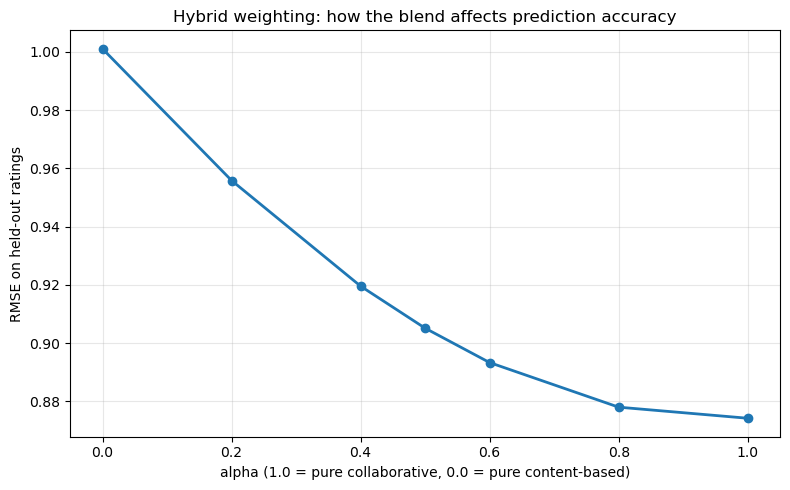

Best alpha: 1.0 (RMSE 0.8742)


In [11]:
# Sweep the hybrid weight alpha to see how the blend affects accuracy
alphas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]
alpha_rmses = [rmse_of(lambda u, m, a=a: predict_hybrid(u, m, alpha=a)) for a in alphas]

plt.figure(figsize=(8, 5))
plt.plot(alphas, alpha_rmses, 'o-', linewidth=2)
plt.xlabel('alpha (1.0 = pure collaborative, 0.0 = pure content-based)')
plt.ylabel('RMSE on held-out ratings')
plt.title('Hybrid weighting: how the blend affects prediction accuracy')
plt.tight_layout()
plt.show()

best_alpha = alphas[int(np.argmin(alpha_rmses))]
print(f"Best alpha: {best_alpha} (RMSE {min(alpha_rmses):.4f})")

### Generating recommendations

Beyond predicting ratings, the practical output of a recommender is a ranked list of movies a user has not yet seen. Below, the hybrid model scores all unrated movies for one user and returns the top ten.

In [12]:
def recommend_top_n(user_id, n=10, alpha=0.7):
    seen = set(train_ratings[train_ratings['userId'] == user_id]['movieId'])
    candidates = [m for m in movie_ids if m not in seen]
    # Score a manageable random subset for speed
    rng = np.random.default_rng(RANDOM_SEED)
    candidates = list(rng.choice(candidates, size=min(500, len(candidates)), replace=False))
    scored = [(m, predict_hybrid(user_id, m, alpha)) for m in candidates]
    scored.sort(key=lambda x: x[1], reverse=True)
    top = scored[:n]
    return [(movies_indexed.loc[m, 'title'], round(score, 2)) for m, score in top]

example_user = user_item.index[0]
print(f"Top 10 hybrid recommendations for user {example_user}:\n")
for title, score in recommend_top_n(example_user):
    print(f"  {score:.2f}   {title}")

Top 10 hybrid recommendations for user 1:

  4.83   Scooby-Doo! Curse of the Lake Monster (2010)
  4.83   Gintama: The Final Chapter - Be Forever Yorozuya (2013)
  4.81   Jump In! (2007)
  4.81   Captain Newman, M.D. (1963)
  4.79   Zoom (2006)
  4.76   Halloweentown High (2004)
  4.76   American Carol, An (2008)
  4.75   The Electric Hotel (1908)
  4.75   Big Top Scooby-Doo! (2012)
  4.75   All Dogs Christmas Carol, An (1998)


---

## Part 6: Reflection

### What this project demonstrates

- Item-item collaborative filtering implemented from scratch, including the user-item matrix, mean-centering, cosine similarity, and similarity-weighted rating prediction
- Content-based filtering implemented from scratch from genre metadata, including multi-hot feature encoding and user genre profiles
- A hybrid model that blends the two with a tunable weight, evaluated by held-out RMSE against baselines
- A practical top-N recommendation function that produces ranked movie lists

### Key takeaways

1. Recommendation is fundamentally a problem of sparsity. More than 98 percent of the user-item matrix is empty, and the entire task is to infer the missing entries from the few that are observed.
2. The two filtering approaches have complementary strengths. Collaborative filtering captures taste patterns that genre labels cannot express but fails on movies with no ratings, while content-based filtering works for any movie with metadata but is limited to surface similarity. The hybrid is designed to draw on whichever signal is stronger for a given prediction.
3. Baselines matter. Comparing against the global mean and the per-user mean shows how much of the predictive accuracy comes from the modeling rather than from simply guessing an average, which is the honest way to report recommender performance.
4. Offline rating accuracy is only part of the picture. RMSE measures how well the model predicts known ratings, but a real recommender must also be evaluated on the quality and diversity of its ranked recommendations, which depends on factors that held-out RMSE does not capture.